In [10]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import confusion_matrix 
from sklearn.model_selection import KFold 
from keras.models import Sequential 
from keras.layers import Dense 
from datetime import datetime 
import warnings 
warnings.filterwarnings ('ignore')

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def assessment(f_data, f_y_feature, f_x_feature, f_index=-1):
    f_fig, f_a = plt.subplots(1, 2, figsize=(16, 4))

    # Histogram (distribution plot)
    sns.histplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')
    f_a[0].set_xlabel(f_x_feature, fontsize=10)

    # Scatter plot
    if f_index >= 0:
        f_color = np.where(f_data.index == f_index, 'r', 'g')  # Fixed Index Selection
        f_a[1].scatter(f_data[f_x_feature], f_data[f_y_feature], c=f_color, edgecolors='w')
        f_a[1].set_xlabel(f_x_feature, fontsize=10)
        f_a[1].set_ylabel(f_y_feature, fontsize=10)
    else:
        sns.scatterplot(x=f_x_feature, y=f_y_feature, data=f_data, ax=f_a[1])
        f_a[1].set_xlabel(f_x_feature, fontsize=10)
        f_a[1].set_ylabel(f_y_feature, fontsize=10)

    plt.show()

def correlation_map(f_data, f_feature, f_number):
    # Find the most correlated features
    f_most_correlated = f_data.corr().nlargest(f_number, f_feature)[f_feature].index
    f_correlation = f_data[f_most_correlated].corr()

    # Create a mask for the upper triangle
    f_mask = np.triu(np.ones_like(f_correlation, dtype=bool))  # Fixed mask assignment

    # Plot the heatmap
    with sns.axes_style("white"):
        f_fig, f_ax = plt.subplots(figsize=(20, 10))
        sns.heatmap(f_correlation, mask=f_mask, vmin=-1, vmax=1, square=True, center=0,
                    annot=True, annot_kws={"size": 8}, cmap="PRGn")

    plt.show()


In [18]:
sns.set() 
start_time= datetime.now()

data=pd.read_csv(r'smart_grid_stability_augmented.csv')
map1 ={'unstable': 0, 'stable': 1} 
data['stabf'] = data['stabf'].replace(map1) 
data =data.sample(frac=1) 

In [19]:
data.head() 

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
59793,7.736233,7.663700,4.948641,5.988998,3.137578,-1.891931,-0.519112,-0.726536,0.077761,0.702472,0.358437,0.307865,0.021147,0
42977,2.709629,2.732621,3.283984,5.006101,3.368382,-1.390451,-0.964334,-1.013597,0.738550,0.977467,0.688025,0.512898,0.068331,0
51573,1.190329,1.740902,6.211660,7.799270,3.740848,-0.588275,-1.444342,-1.708231,0.255805,0.239233,0.394001,0.080261,-0.041837,1
53450,5.858016,4.478434,6.973412,7.770710,4.056539,-1.285332,-0.806007,-1.965200,0.596790,0.121850,0.309962,0.960542,0.053894,0
24463,9.632859,6.916970,5.203109,0.878894,3.068386,-1.112700,-0.658518,-1.297168,0.744999,0.846262,0.353322,0.175794,0.043229,0


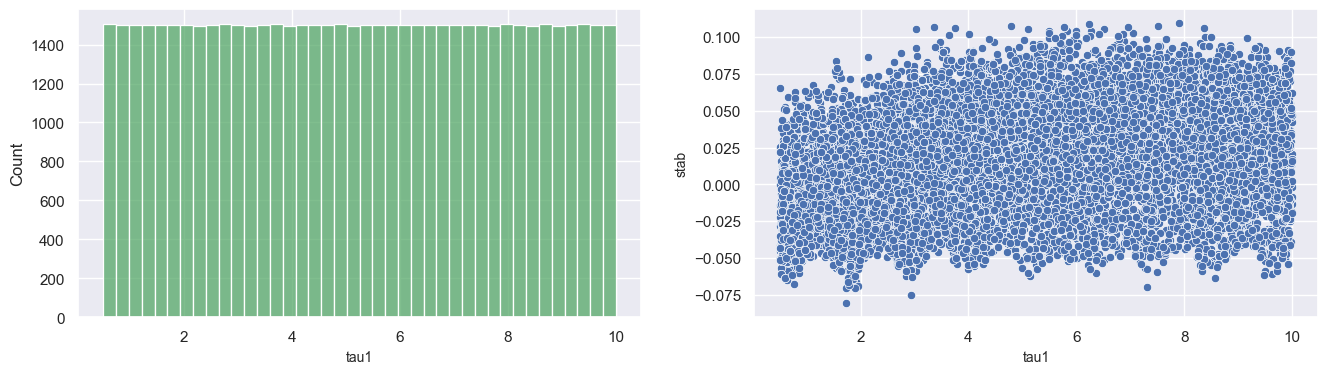

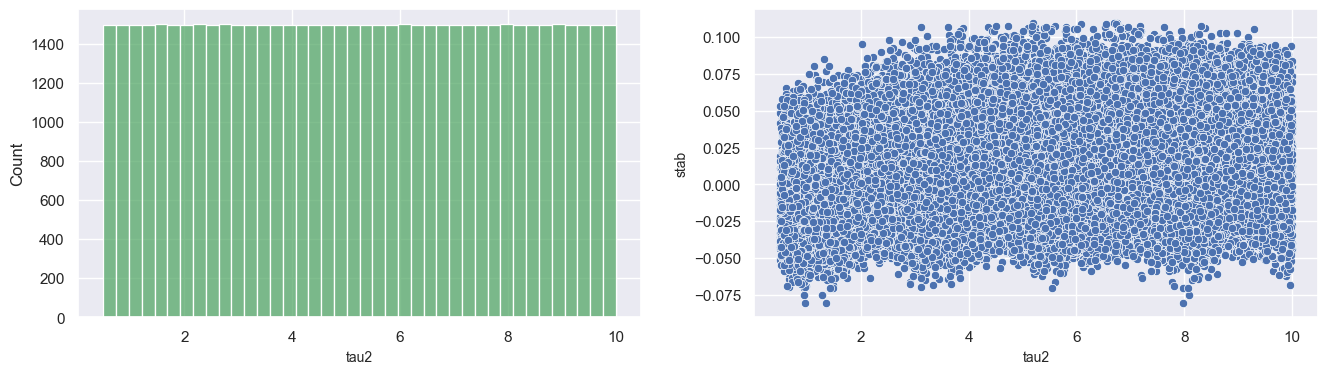

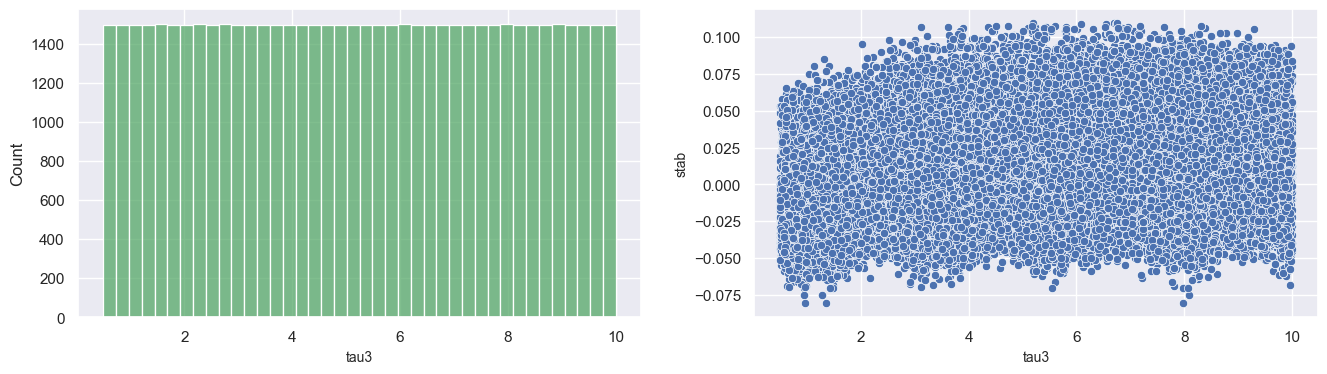

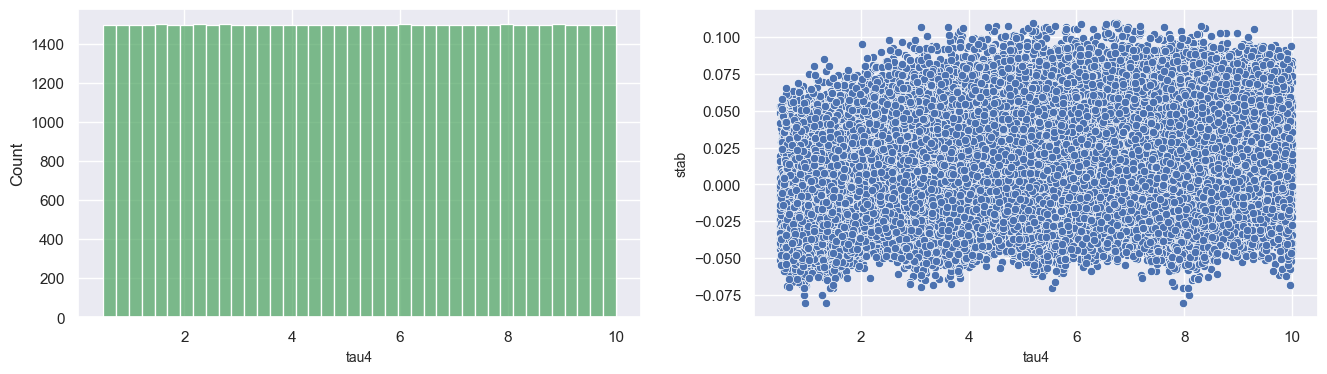

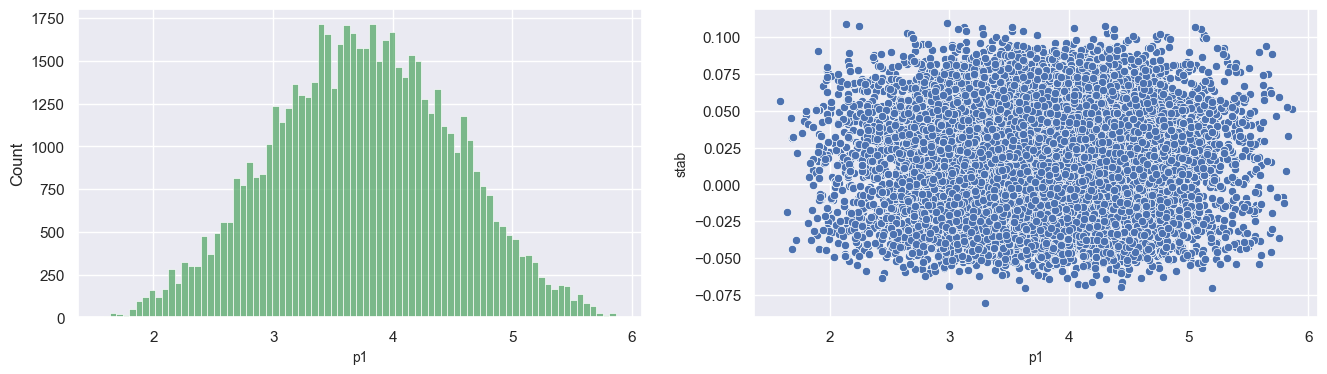

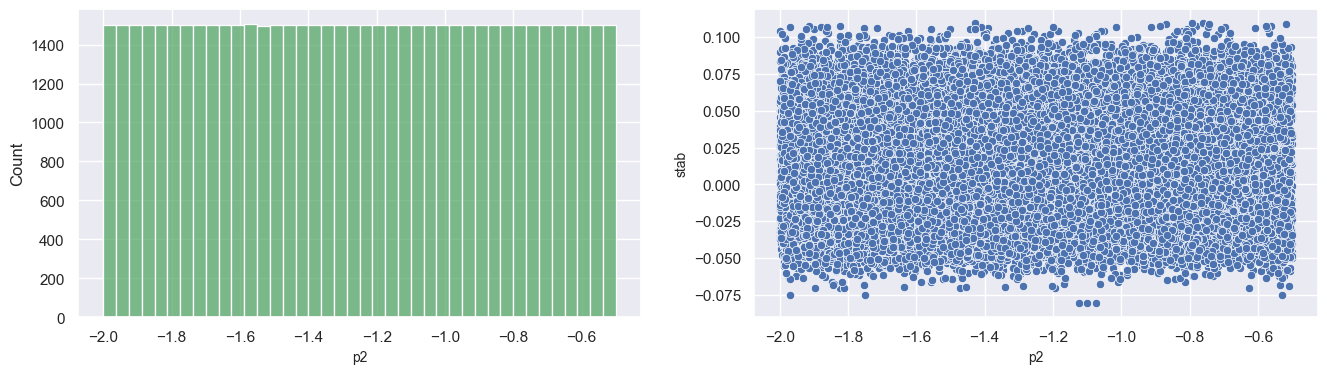

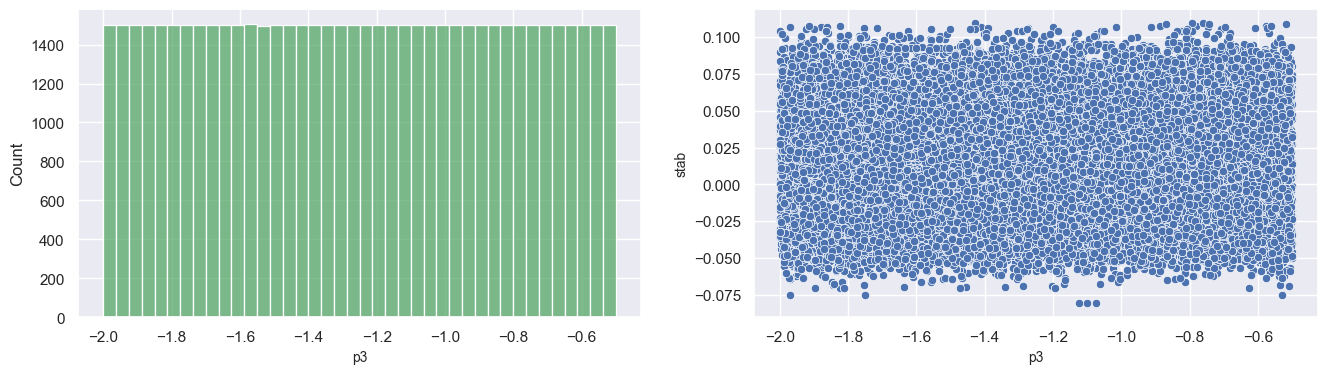

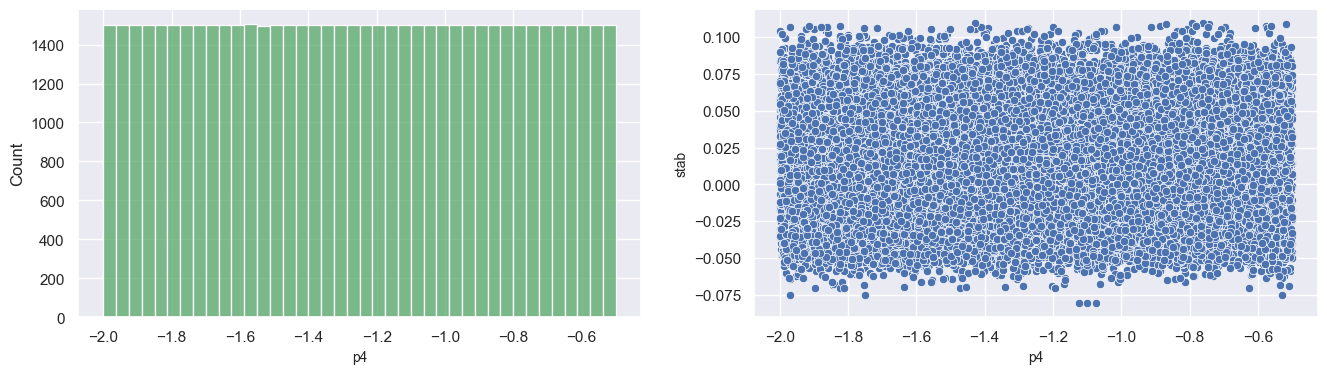

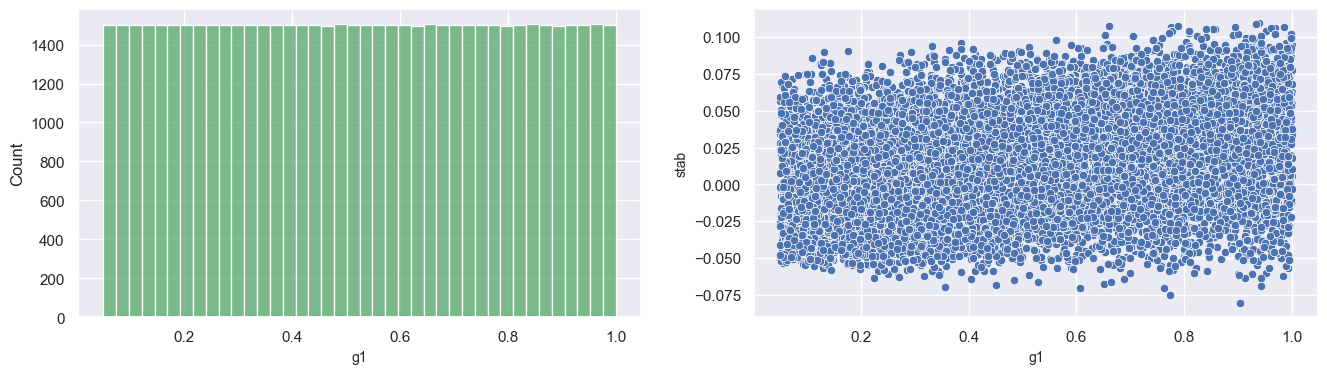

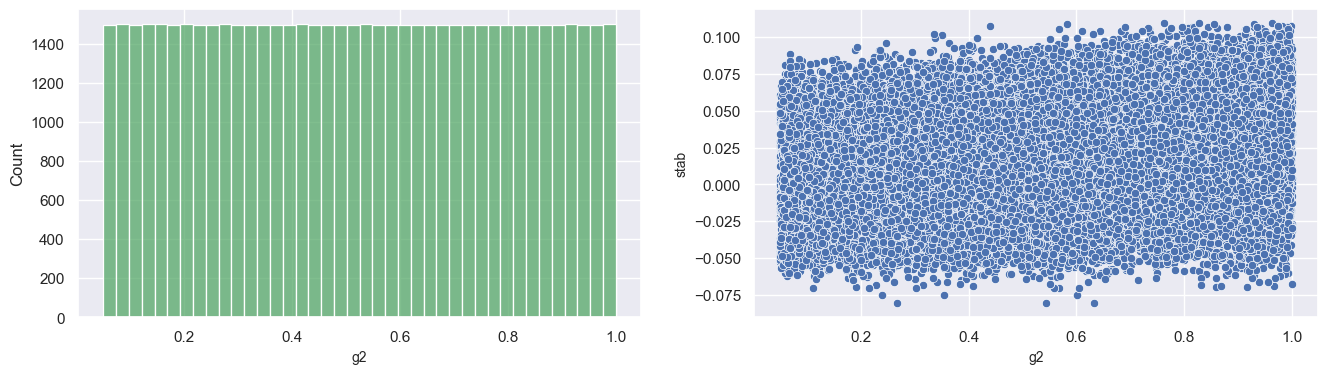

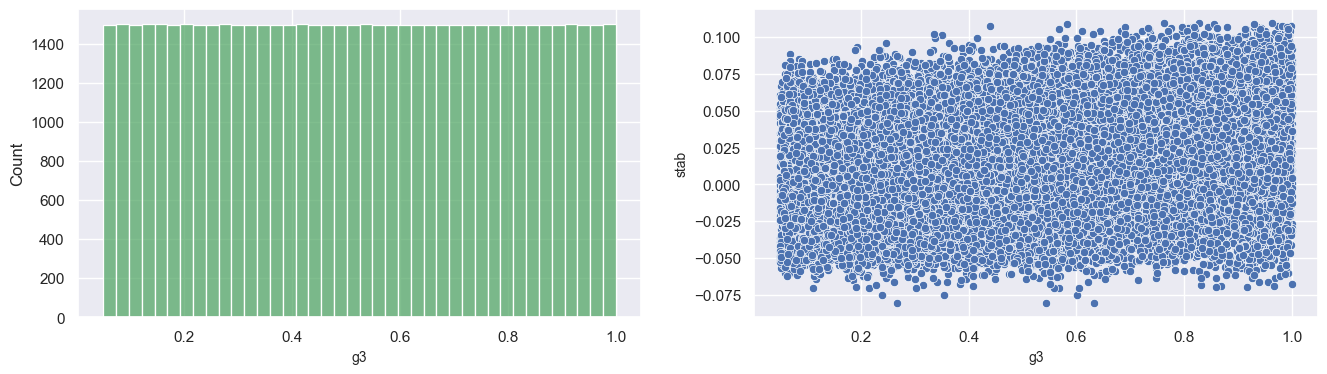

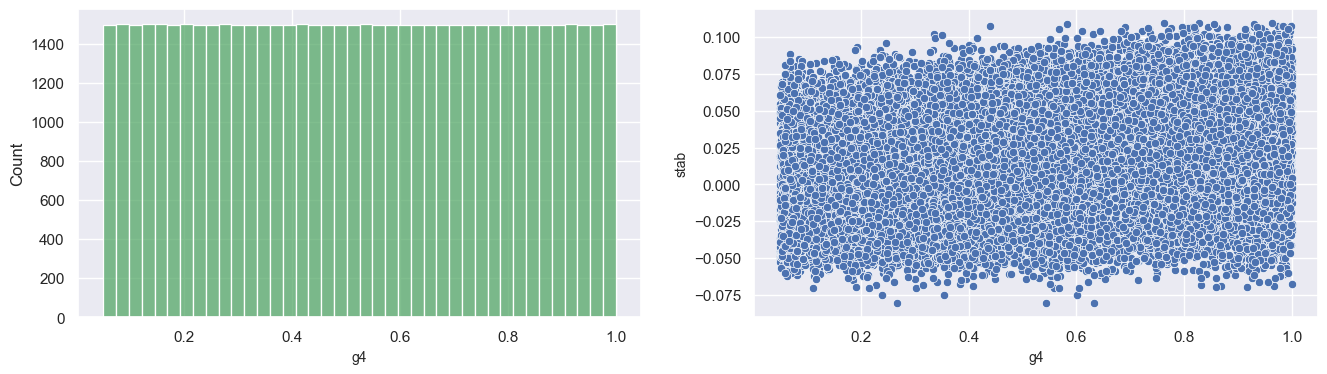

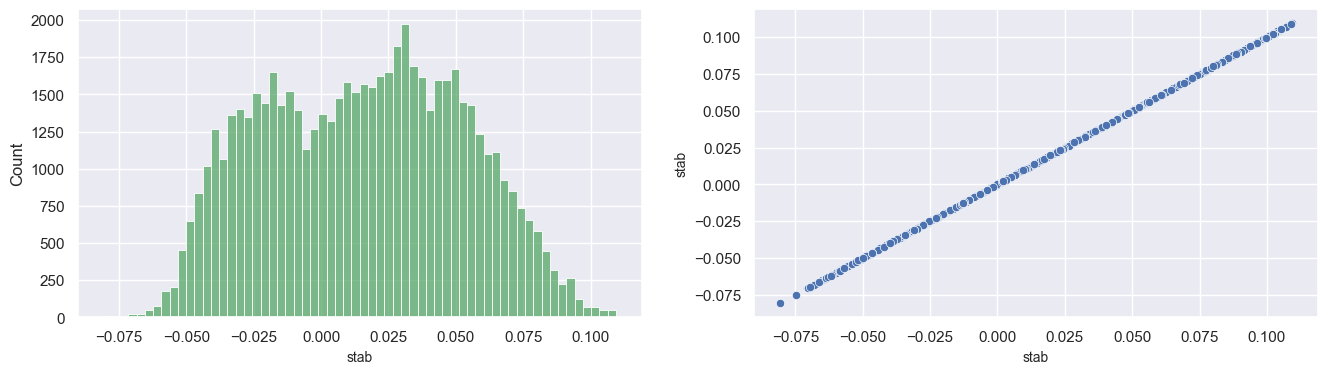

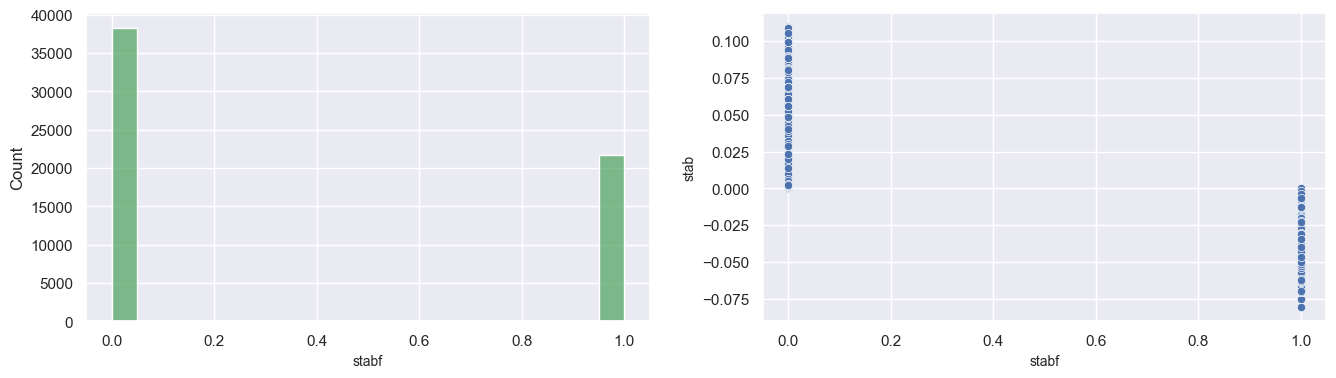

In [20]:
for column in data.columns: 
    assessment(data, 'stab', column, -1) 

In [21]:
data.p1.skew()

np.float64(-0.012688423269883422)

In [22]:
print(f'Split of "unstable" (0) and "stable" (1) observations in the original dataset:') 
print(data['stabf'].value_counts (normalize=True))

Split of "unstable" (0) and "stable" (1) observations in the original dataset:
stabf
0    0.638
1    0.362
Name: proportion, dtype: float64


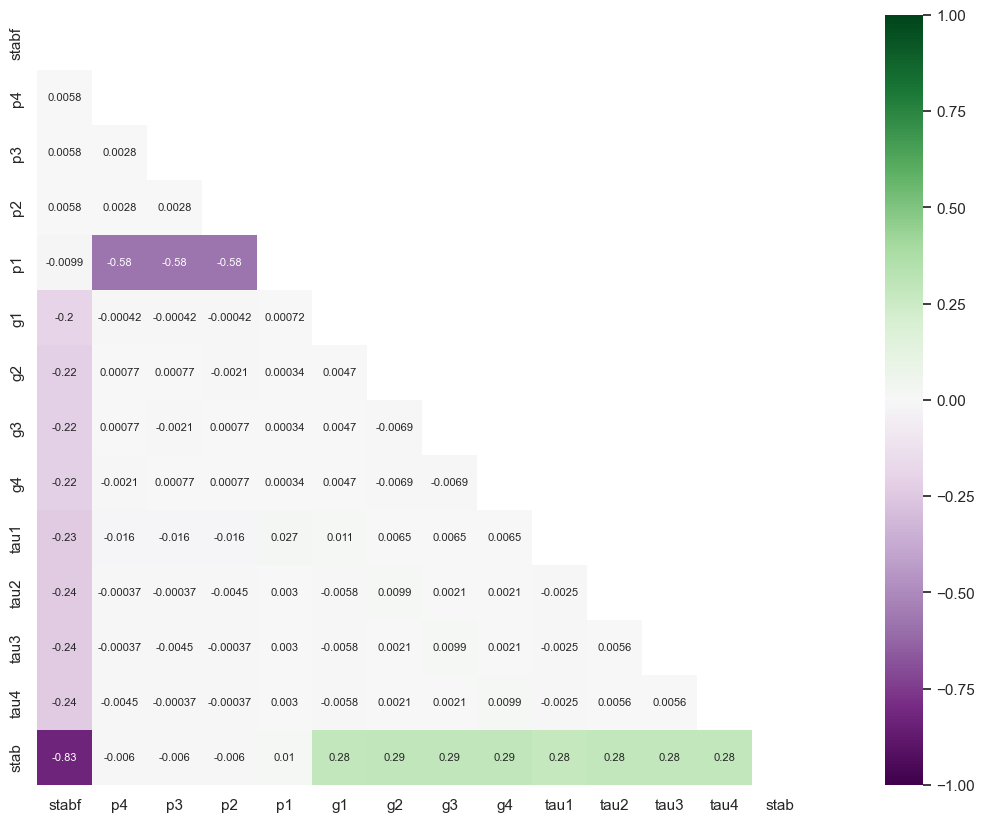

In [23]:
correlation_map(data,'stabf',14)

In [24]:
X= data.iloc[:, :12] 
y= data.iloc[:, 13] 
X_training =X.iloc[:54000,:] 
y_training =y.iloc[:54000]
X_testing =X.iloc[54000:, :] 
y_testing =y.iloc[54000:]  
ratio_training= y_training.value_counts (normalize=True) 
ratio_testing =y_testing.value_counts (normalize=True) 
ratio_training, ratio_testing 


(stabf
 0    0.637833
 1    0.362167
 Name: proportion, dtype: float64,
 stabf
 0    0.6395
 1    0.3605
 Name: proportion, dtype: float64)

In [25]:
X_training = X_training.values 
y_training =y_training.values 
X_testing =X_testing.values 
y_testing =y_testing.values

In [26]:
scaler= StandardScaler() 
X_training =scaler.fit_transform(X_training) 
X_testing =scaler.transform(X_testing) 

In [27]:
classifier =Sequential()
classifier.add(Dense(units= 24, kernel_initializer = 'uniform', activation = 'relu', input_dim = 12)) 
#Second hidden Layer 
classifier.add(Dense (units= 24, kernel_initializer = 'uniform', activation ='relu')) 
#Third hidden Layer 
classifier.add(Dense (units =12, kernel_initializer ='uniform', activation= 'relu')) 
#Single-node output Layer 
classifier.add(Dense (units = 1, kernel_initializer = 'uniform', activation = 'sigmoid')) 
#ANN compilation 
classifier.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics = ['accuracy'])


In [32]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold

# Check if GPU is available
print("Num GPUs Available:", len(tf.config.experimental.list_physical_devices('GPU')))

# Build Model Function
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_training.shape[1],)),  # Reduced neurons
        layers.Dense(32, activation='relu'),  
        layers.Dense(1, activation='sigmoid')  
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# K-Fold Cross Validation
cross_val_round = 1 
kf = KFold(5, shuffle=True, random_state=10)  # Reduce folds from 10 → 5

print(f'Model evaluation\n')

for train_index, val_index in kf.split(X_training): 
    x_train, x_val = X_training[train_index], X_training[val_index] 
    y_train, y_val = y_training[train_index], y_training[val_index] 

    classifier = build_model()  # Creating a fresh model for each fold

    print(f'🚀 Training Fold {cross_val_round}/5...')

    # Reduce epochs + use EarlyStopping
    early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

    classifier.fit(
        x_train, y_train, 
        epochs=10,  # Reduced from 20 → 10
        batch_size=64,  # Increased batch size from 32 → 64
        validation_split=0.1,  # Only use 90% of training data
        verbose=1,  
        callbacks=[early_stop]
    )

    classifier_loss, classifier_accuracy = classifier.evaluate(x_val, y_val, verbose=1)

    print(f'✅ Round {cross_val_round} | Loss: {classifier_loss:.4f} | Accuracy: {classifier_accuracy * 100:.2f}%')
    cross_val_round += 1


Num GPUs Available: 0
Model evaluation

🚀 Training Fold 1/5...
Epoch 1/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8167 - loss: 0.4052 - val_accuracy: 0.9220 - val_loss: 0.1834
Epoch 2/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9293 - loss: 0.1657 - val_accuracy: 0.9410 - val_loss: 0.1385
Epoch 3/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9509 - loss: 0.1203 - val_accuracy: 0.9616 - val_loss: 0.1050
Epoch 4/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9641 - loss: 0.0954 - val_accuracy: 0.9655 - val_loss: 0.0883
Epoch 5/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9685 - loss: 0.0822 - val_accuracy: 0.9681 - val_loss: 0.0793
Epoch 6/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9704 - loss: 0.0729 - val_accuracy: 0.9681 - val_loss: 0.0787
Epoch 7/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9737 - loss: 0.0672 - val_accuracy: 0.9692 - val_loss: 0.0730
Epoch 8/10
608/608 ━━━━━━━━

In [35]:
y_pred = classifier.predict(X_testing)  # Get predicted probabilities
y_pred = np.where(y_pred <= 0.5, 0, 1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [36]:
cm = pd.DataFrame(data=confusion_matrix(y_testing, y_pred, labels=[0, 1]),
                  index=["Actual Unstable", "Actual Stable"],
                  columns=["Predicted Unstable", "Predicted Stable"])

cm


,Predicted Unstable,Predicted Stable
Actual Unstable,3781,56
Actual Stable,127,2036


In [37]:
print(f'Accuracy per the confusion matrix: {((cm.iloc[0, 0] + cm.iloc[1, 1]) / len(y_testing) * 100):.2f}%')


Accuracy per the confusion matrix: 96.95%
